# Cuaderno 6 — Explicabilidad de Modelos con SHAP (XAI)

La **Explicabilidad de la IA (XAI)** es crítica en ciberseguridad porque permite:
- Entender _por qué_ un modelo marcó un archivo como malicioso.
- Generar evidencia auditable para equipos legales o de cumplimiento.
- Detectar sesgo en el modelo y guiar mejoras.

**SHAP** (_SHapley Additive exPlanations_) asigna a cada característica una
contribución al valor predicho, basándose en la teoría de juegos cooperativos
(valores de Shapley).

$$\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!(|F|-|S|-1)!}{|F|!} [f(S \cup \{i\}) - f(S)]$$

Donde $F$ es el conjunto de características y $\phi_i$ es la contribución de
la característica $i$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

SEED = 42
np.random.seed(SEED)
shap.initjs()  # Inicializar visualizaciones JS de SHAP
print(f"SHAP versión: {shap.__version__}")

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


SHAP versión: 0.44.1


## 1. Preparar dataset (reutilizamos características PE del Cuaderno 3)

In [2]:
def generar_dataset_malware(n_benign=1700, n_malicious=300, seed=42):
    rng = np.random.default_rng(seed)
    benign = pd.DataFrame({
        "entry_point":       rng.integers(4096, 16384,   size=n_benign),
        "num_sections":      rng.integers(3, 7,           size=n_benign),
        "entropia_max":      rng.uniform(4.0, 6.5,        size=n_benign),
        "num_importaciones": rng.integers(20, 150,        size=n_benign),
        "num_dlls":          rng.integers(2, 12,          size=n_benign),
        "file_size":         rng.integers(50_000, 2_000_000, size=n_benign),
        "has_debug":         rng.integers(0, 2,           size=n_benign),
        "label":             0
    })
    malicious = pd.DataFrame({
        "entry_point":       rng.integers(0, 4096,        size=n_malicious),
        "num_sections":      rng.integers(8, 20,          size=n_malicious),
        "entropia_max":      rng.uniform(6.8, 8.0,        size=n_malicious),
        "num_importaciones": rng.integers(200, 600,       size=n_malicious),
        "num_dlls":          rng.integers(15, 40,         size=n_malicious),
        "file_size":         rng.integers(10_000, 500_000, size=n_malicious),
        "has_debug":         np.zeros(n_malicious, dtype=int),
        "label":             1
    })
    return pd.concat([benign, malicious], ignore_index=True).sample(frac=1, random_state=seed)

FEATURES = ["entry_point", "num_sections", "entropia_max",
            "num_importaciones", "num_dlls", "file_size", "has_debug"]

df = generar_dataset_malware()
X, y = df[FEATURES], df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
print(f"Entrenamiento: {X_train.shape} | Prueba: {X_test.shape}")

Entrenamiento: (1600, 7) | Prueba: (400, 7)


## 2. Entrenar Random Forest

In [3]:
rf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["Benign", "Malicious"]))

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00       340
   Malicious       1.00      1.00      1.00        60

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



## 3. Calcular valores SHAP

`TreeExplainer` es el explainer más eficiente para árboles de decisión y bosques
aleatorios. Calcula valores SHAP exactos en tiempo polinómico.

In [4]:
# Usamos una muestra representativa para acelerar el cálculo
X_muestra = X_test.sample(100, random_state=SEED)

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_muestra)

# shap_values es una lista: [clase_0, clase_1]
# Usamos clase_1 (malicious)
shap_class1 = shap_values[1]
print(f"Forma de los valores SHAP (clase Malicious): {shap_class1.shape}")
print(f"Suma de contribuciones para muestra 0: {shap_class1[0].sum():.4f}")
print(f"Valor base del modelo:                {explainer.expected_value[1]:.4f}")

Forma de los valores SHAP (clase Malicious): (100, 7)
Suma de contribuciones para muestra 0: -0.1499
Valor base del modelo:                0.1499


## 4. Importancia global de características (SHAP summary plot)

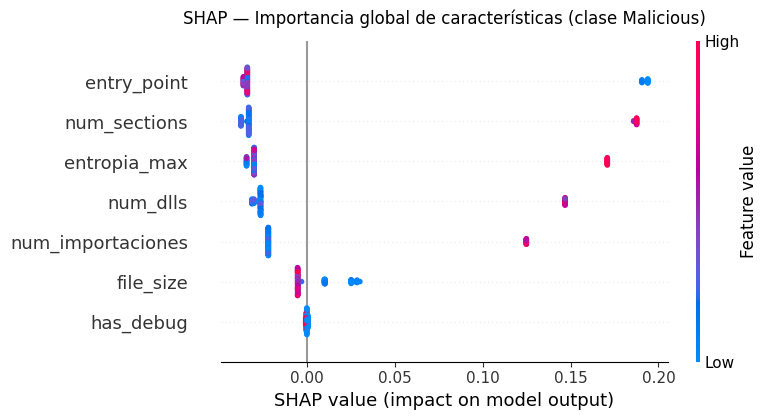

In [5]:
# Gráfico de importancia global (beeswarm)
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_class1, X_muestra, show=False)
plt.title("SHAP — Importancia global de características (clase Malicious)", pad=12)
plt.tight_layout()
plt.show()

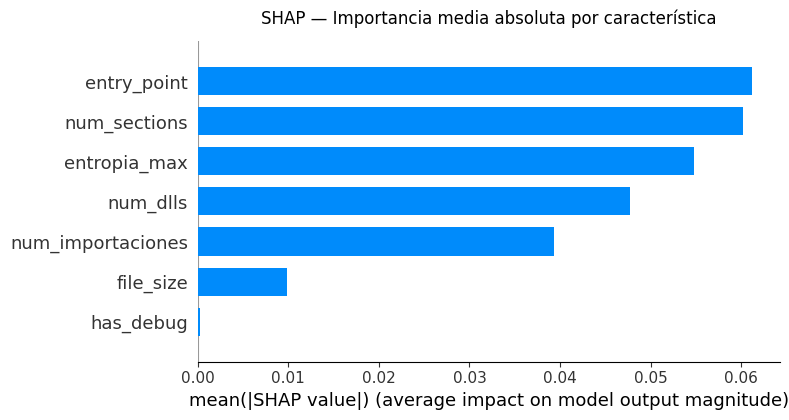

In [6]:
# Gráfico de barras (importancia media absoluta)
plt.figure(figsize=(8, 4))
shap.summary_plot(shap_class1, X_muestra, plot_type="bar", show=False)
plt.title("SHAP — Importancia media absoluta por característica", pad=12)
plt.tight_layout()
plt.show()

## 5. Explicación individual (force plot)

El **force plot** muestra qué características _empujan_ la predicción hacia
malicioso (rojo) o hacia benigno (azul) para una muestra concreta.

In [7]:
# Encontrar un verdadero positivo (predicho malicioso, es malicioso)
y_pred_muestra = rf.predict(X_muestra)
y_true_muestra = y_test.loc[X_muestra.index]

tp_idx = X_muestra[(y_pred_muestra == 1) & (y_true_muestra.values == 1)].index
if len(tp_idx) == 0:
    idx = X_muestra.index[0]   # fallback
else:
    idx = tp_idx[0]

muestra_pos = X_muestra.loc[[idx]]
shap_vals_pos = explainer.shap_values(muestra_pos)[1][0]

print(f"Muestra analizada (index={idx}):")
print(muestra_pos.to_string())
print(f"Predicción: {'Malicious' if rf.predict(muestra_pos)[0] == 1 else 'Benign'}")
print(f"Probabilidad malicioso: {rf.predict_proba(muestra_pos)[0][1]:.4f}")
print()
print("Contribuciones SHAP por característica:")
for feat, val in sorted(zip(FEATURES, shap_vals_pos), key=lambda x: abs(x[1]), reverse=True):
    barra = "█" * int(abs(val) * 100)
    signo = "+" if val > 0 else "-"
    print(f"  {feat:<25} {signo}{abs(val):.4f}  {barra[:30]}")

Muestra analizada (index=1705):
      entry_point  num_sections  entropia_max  num_importaciones  num_dlls  file_size  has_debug
1705         2019             9      6.853723                328        22     280747          0
Predicción: Malicious
Probabilidad malicioso: 1.0000

Contribuciones SHAP por característica:
  entry_point               +0.1939  ███████████████████
  num_sections              +0.1859  ██████████████████
  entropia_max              +0.1709  █████████████████
  num_dlls                  +0.1469  ██████████████
  num_importaciones         +0.1249  ████████████
  file_size                 +0.0269  ██
  has_debug                 +0.0007  


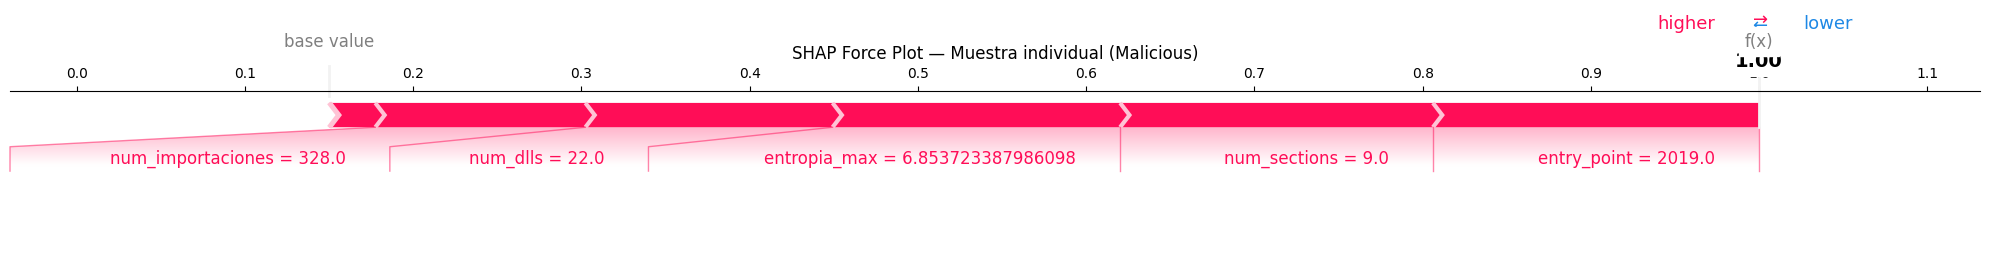


✓ Cuaderno 6 completado.


In [8]:
# Force plot estático (matplotlib)
shap.force_plot(
    base_value    = explainer.expected_value[1],
    shap_values   = shap_vals_pos,
    features      = muestra_pos.iloc[0],
    feature_names = FEATURES,
    matplotlib    = True,
    show          = False
)
plt.title("SHAP Force Plot — Muestra individual (Malicious)")
plt.tight_layout()
plt.show()

print("\n✓ Cuaderno 6 completado.")

## 6. Análisis de dependencia entre características

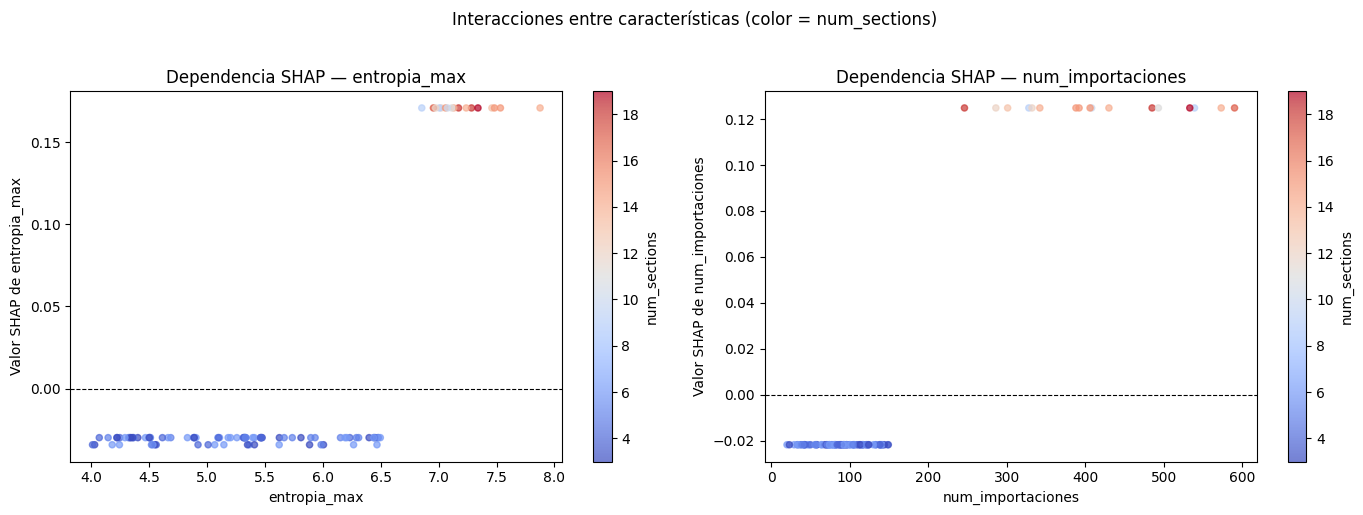

In [9]:
# Dependence plot: entropía_max vs sus interacciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feature in zip(axes, ["entropia_max", "num_importaciones"]):
    feat_idx = FEATURES.index(feature)
    ax.scatter(
        X_muestra[feature],
        shap_class1[:, feat_idx],
        c=X_muestra["num_sections"],
        cmap="coolwarm", s=20, alpha=0.7
    )
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_xlabel(feature)
    ax.set_ylabel(f"Valor SHAP de {feature}")
    ax.set_title(f"Dependencia SHAP — {feature}")
    plt.colorbar(ax.collections[0], ax=ax, label="num_sections")

plt.suptitle("Interacciones entre características (color = num_sections)", y=1.02)
plt.tight_layout()
plt.show()